# Bruno Reitano Figuerola | RA: 24011707

In [11]:
import random
import time
import statistics
import sys
import matplotlib.pyplot as plt


sys.setrecursionlimit(200000)

In [12]:
def insertion_sort(arr): # O(n²) no pior cenário e O(n) no melhor cenário
    movimentacoes1 = 0

    for i in range(1, len(arr)):
        temp = arr[i]
        j = i - 1

        while(j >= 0 and arr[j] > temp):
            arr[j + 1] = arr[j]
            movimentacoes1 += 1
            j -= 1

        arr[j + 1] = temp
    
    return arr, movimentacoes1

# -----------------------------------------------------------------------

"""
como ele é cego e sempre corta o vetor no meio, não importa se o vetor está ordenado, invertido ou embaralhado:
a árvore sempre terá o mesmo tamanho e ele sempre fará o mesmo número de passos. Logo O(n log n)
"""

def merge_sort(arr): 
    movimentacoes2 = 0

    if len(arr) <= 1: return arr, 0

    middle = len(arr) // 2
    leftArray = arr[:middle]
    rightArray = arr[middle:]

    _, mov_left = merge_sort(leftArray)
    _, mov_right = merge_sort(rightArray)
    movimentacoes2 += (mov_left + mov_right)

    _, mov_merge = merge(leftArray, rightArray, arr)
    movimentacoes2 += mov_merge

    return arr, movimentacoes2



def merge(leftArray, rightArray, arr):

    i = l = r = 0
    movimentacoes2 = 0

    while(l < len(leftArray) and r < len(rightArray)):

        if leftArray[l] < rightArray[r]:
            arr[i] = leftArray[l]
            l += 1

        else:
            arr[i] = rightArray[r]
            r += 1
        
        i += 1
        movimentacoes2 += 1

    while(l < len(leftArray)):
        arr[i] = leftArray[l]
        l += 1
        i += 1
        movimentacoes2 += 1

    while(r < len(rightArray)):
        arr[i] = rightArray[r]
        r += 1
        i += 1
        movimentacoes2 += 1

    return arr, movimentacoes2

# -----------------------------------------------------------------------

def quick_sort(arr, start, end): # Caso ideal e médio: O(n log n), pior caso: O(n²)
    movimentacao3 = 0
    if start < end:
        pivot_idx, mov_part = partition(arr, start, end)
        
        _, mov_esq = quick_sort(arr, start, pivot_idx - 1)
        _, mov_dir = quick_sort(arr, pivot_idx + 1, end)
        
        movimentacao3 = mov_part + mov_esq + mov_dir
    return arr, movimentacao3

def partition(arr, start, end):
    movimentacao3 = 0

    pivo_aleatorio = random.randint(start, end)

    arr[pivo_aleatorio], arr[end] = arr[end], arr[pivo_aleatorio]
    movimentacao3 += 1

    pivot = arr[end]
    i = start - 1

    for j in range(start, end):
        if arr[j] < pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
            movimentacao3 += 1
            
    arr[i + 1], arr[end] = arr[end], arr[i + 1]
    movimentacao3 += 1
    return i + 1, movimentacao3


In [13]:
# testes

tamanhos = [1000, 10000, 100000]
num_execucoes = 3

algoritmos = {
    "Insertion Sort": insertion_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

resultados = [] 

for n in tamanhos:
    print(f"\n{'='*40}")
    print(f"Testando para vetor de tamanho: {n}")
    print(f"{'='*40}")
    
    vetor_original = [random.randint(1, n) for _ in range(n)]
    
    for nome_algo, funcao_sort in algoritmos.items():
        print(f"\n-> Executando {nome_algo}...")
        tempos = []
        operacoes_lista = []
        
        for i in range(num_execucoes):
            # criar copia vetor original
            arr_copia = vetor_original.copy()
            
            # medir o tempo
            t_inicio = time.perf_counter()

            if nome_algo == "Insertion Sort":
                _, operacoes = insertion_sort(arr_copia)
    
            elif nome_algo == "Merge Sort":
                _, operacoes = merge_sort(arr_copia)

            elif nome_algo == "Quick Sort":
                _, operacoes = quick_sort(arr_copia, 0, len(arr_copia) - 1)
            
            t_fim = time.perf_counter()
            
            tempo_execucao = t_fim - t_inicio
            tempos.append(tempo_execucao)
            operacoes_lista.append(operacoes)
            
            print(f"   Execução {i+1}: {tempo_execucao:.6f} s")
            
        tempo_medio = statistics.mean(tempos)
        desvio_padrao = statistics.stdev(tempos) if num_execucoes > 1 else 0
        media_operacoes = int(statistics.mean(operacoes_lista))
        
        resultados.append({
            "Tamanho": n,
            "Algoritmo": nome_algo,
            "Tempo Medio (s)": tempo_medio,
            "Desvio Padrao (s)": desvio_padrao,
            "Operacoes (Media)": media_operacoes
        })
        print(f"   [RESUMO] Média: {tempo_medio:.6f}s | Desvio: {desvio_padrao:.6f}s | Ops: {media_operacoes}")


Testando para vetor de tamanho: 1000

-> Executando Insertion Sort...
   Execução 1: 0.031528 s
   Execução 2: 0.030135 s
   Execução 3: 0.029854 s
   [RESUMO] Média: 0.030506s | Desvio: 0.000897s | Ops: 255494

-> Executando Merge Sort...
   Execução 1: 0.001997 s
   Execução 2: 0.001959 s
   Execução 3: 0.001961 s
   [RESUMO] Média: 0.001972s | Desvio: 0.000021s | Ops: 9976

-> Executando Quick Sort...
   Execução 1: 0.001777 s
   Execução 2: 0.001618 s
   Execução 3: 0.001440 s
   [RESUMO] Média: 0.001612s | Desvio: 0.000169s | Ops: 6854

Testando para vetor de tamanho: 10000

-> Executando Insertion Sort...
   Execução 1: 3.239517 s
   Execução 2: 3.038650 s
   Execução 3: 3.039300 s
   [RESUMO] Média: 3.105822s | Desvio: 0.115783s | Ops: 25240765

-> Executando Merge Sort...
   Execução 1: 0.027179 s
   Execução 2: 0.025727 s
   Execução 3: 0.026341 s
   [RESUMO] Média: 0.026416s | Desvio: 0.000729s | Ops: 133616

-> Executando Quick Sort...
   Execução 1: 0.018689 s
   Execução 

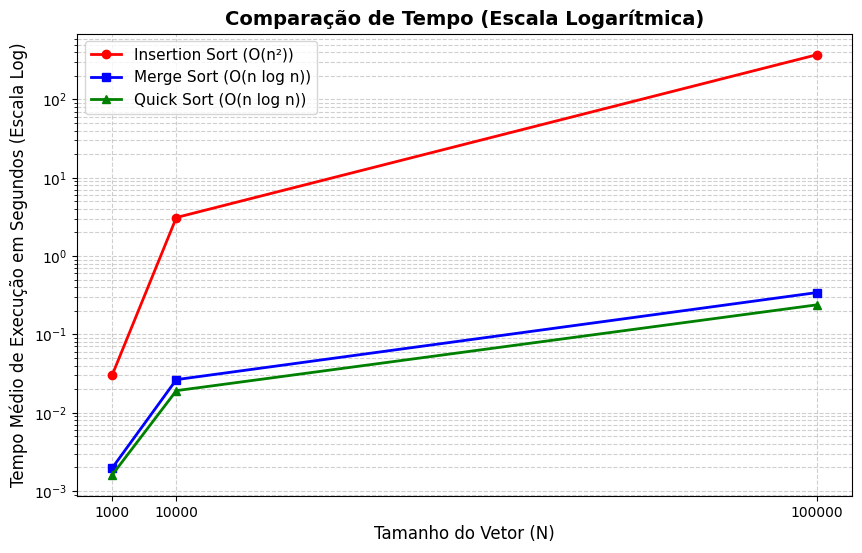

In [15]:
dados_insertion = [r for r in resultados if r["Algoritmo"] == "Insertion Sort"]
dados_merge = [r for r in resultados if r["Algoritmo"] == "Merge Sort"]
dados_quick = [r for r in resultados if r["Algoritmo"] == "Quick Sort"]

plt.figure(figsize=(10, 6))

plt.plot([d["Tamanho"] for d in dados_insertion], [d["Tempo Medio (s)"] for d in dados_insertion], marker='o', label='Insertion Sort (O(n²))', color='red', linewidth=2)
plt.plot([d["Tamanho"] for d in dados_merge], [d["Tempo Medio (s)"] for d in dados_merge], marker='s', label='Merge Sort (O(n log n))', color='blue', linewidth=2)
plt.plot([d["Tamanho"] for d in dados_quick], [d["Tempo Medio (s)"] for d in dados_quick], marker='^', label='Quick Sort (O(n log n))', color='green', linewidth=2)

# O PULO DO GATO: Transforma o eixo Y em escala logarítmica
plt.yscale('log')

plt.title('Comparação de Tempo (Escala Logarítmica)', fontsize=14, fontweight='bold')
plt.xlabel('Tamanho do Vetor (N)', fontsize=12)
plt.ylabel('Tempo Médio de Execução em Segundos (Escala Log)', fontsize=12)
plt.xticks(tamanhos)
plt.legend(fontsize=11)
plt.grid(True, which="both", linestyle='--', alpha=0.6) # 'which="both"' ajuda a ver as linhas da grade logarítmica

plt.show()